# Digital Marketing ConversionRate Analysis

## Notebook Purpose

This notebook applies Day 1 Machine Learning and Linear Regression concepts to a digital marketing dataset.

The goal is to understand the data, explore important relationships, and build regression models to predict `ConversionRate`.

I will build this notebook step by step like a professional analyst:

1. Understand the business problem
2. Load and inspect the data
3. Check data quality
4. Explore the data visually
5. Apply statistics concepts
6. Build Simple Linear Regression
7. Understand residuals and least squares
8. Build Multiple Linear Regression
9. Evaluate the model
10. Interpret results in business language

# Code: Install packages

In [2]:
#%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn statsmodels
#%pip install statsmodels
#%pip install scikit-learn

In [3]:
# Kaggle dataset downloader
import kagglehub

# File handling
from pathlib import Path

# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Statistical regression
import statsmodels.api as sm

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [4]:
# Download latest version from Kaggle

path = kagglehub.dataset_download(
    "rabieelkharoua/predict-conversion-in-digital-marketing-dataset"
)

print("Path to dataset files:")
print(path)

Path to dataset files:
/Users/ruturajmokashi/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1


In [5]:
# Convert downloaded path into a Path object
dataset_path = Path(path)

# Show all files in the downloaded dataset folder
files = list(dataset_path.rglob("*"))

print("Files found in dataset folder:")
for file in files:
    print(file)

Files found in dataset folder:
/Users/ruturajmokashi/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1/digital_marketing_campaign_dataset.csv


In [6]:
# Find all CSV files in the downloaded dataset folder
csv_files = list(dataset_path.rglob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print(file)

# Load the first CSV file
csv_path = csv_files[0]

df = pd.read_csv(csv_path)

print("Dataset loaded successfully.")
print("CSV used:", csv_path)
print("Dataset shape:", df.shape)

df.head()

CSV files found:
/Users/ruturajmokashi/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1/digital_marketing_campaign_dataset.csv
Dataset loaded successfully.
CSV used: /Users/ruturajmokashi/.cache/kagglehub/datasets/rabieelkharoua/predict-conversion-in-digital-marketing-dataset/versions/1/digital_marketing_campaign_dataset.csv
Dataset shape: (8000, 20)


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,"6,497.8701",0.0439,0.0880,0,2.3990,7.3968,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,"3,898.6686",0.1557,0.1827,42,2.9171,5.3525,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,"1,546.4296",0.2775,0.0764,2,8.2236,13.7949,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.5259,0.1376,0.0880,47,4.5409,14.6884,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,"1,678.0436",0.2529,0.1099,0,2.0468,13.9934,6,6,6,8,4345,IsConfid,ToolConfid,1


# Data Inspection

In [7]:
#df.shape


In [8]:
#df.head(5)

In [9]:
#df.columns.tolist()

In [10]:
# Check the size of the dataset.
# This shows: (number of rows, number of columns)

print("Dataset shape:")
print(df.shape)


# Show all column names.
# This helps us understand what information is available in the dataset.

print("\nColumn names:")
print(df.columns.tolist())


# Show data types for each column.
# int64 / float64 = numeric columns
# object = text or categorical columns

print("\nData types:")
display(df.dtypes)


# Show the first 5 rows.
# This helps us visually inspect the dataset.

print("\nFirst 5 rows:")
display(df.head())

Dataset shape:
(8000, 20)

Column names:
['CustomerID', 'Age', 'Gender', 'Income', 'CampaignChannel', 'CampaignType', 'AdSpend', 'ClickThroughRate', 'ConversionRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks', 'PreviousPurchases', 'LoyaltyPoints', 'AdvertisingPlatform', 'AdvertisingTool', 'Conversion']

Data types:


CustomerID               int64
Age                      int64
Gender                  object
Income                   int64
CampaignChannel         object
CampaignType            object
AdSpend                float64
ClickThroughRate       float64
ConversionRate         float64
WebsiteVisits            int64
PagesPerVisit          float64
TimeOnSite             float64
SocialShares             int64
EmailOpens               int64
EmailClicks              int64
PreviousPurchases        int64
LoyaltyPoints            int64
AdvertisingPlatform     object
AdvertisingTool         object
Conversion               int64
dtype: object


First 5 rows:


,CustomerID,Age,Gender,Income,CampaignChannel,CampaignType,AdSpend,ClickThroughRate,ConversionRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdvertisingPlatform,AdvertisingTool,Conversion
0,8000,56,Female,136912,Social Media,Awareness,"6,497.8701",0.0439,0.0880,0,2.3990,7.3968,19,6,9,4,688,IsConfid,ToolConfid,1
1,8001,69,Male,41760,Email,Retention,"3,898.6686",0.1557,0.1827,42,2.9171,5.3525,5,2,7,2,3459,IsConfid,ToolConfid,1
2,8002,46,Female,88456,PPC,Awareness,"1,546.4296",0.2775,0.0764,2,8.2236,13.7949,0,11,2,8,2337,IsConfid,ToolConfid,1
3,8003,32,Female,44085,PPC,Conversion,539.5259,0.1376,0.0880,47,4.5409,14.6884,89,2,2,0,2463,IsConfid,ToolConfid,1
4,8004,60,Female,83964,PPC,Conversion,"1,678.0436",0.2529,0.1099,0,2.0468,13.9934,6,6,6,8,4345,IsConfid,ToolConfid,1


# 3. Missing Values and Duplicate Check

Before doing analysis or building a model, I need to check data quality.

In this step, I check:

- missing values
- duplicate rows

Missing values can create problems in analysis and machine learning models.

Duplicate rows can bias the analysis because the same record may be counted more than once.

In [11]:
# Check missing values in each column.
# If a column shows 0, it means there are no missing values in that column.

missing_values = df.isnull().sum()

print("Missing values per column:")
display(missing_values)


# Check total missing values in the full dataset.

total_missing = df.isnull().sum().sum()

print("\nTotal missing values:")
print(total_missing)


# Check duplicate rows.
# A duplicate row means the exact same row appears more than once.

duplicate_rows = df.duplicated().sum()

print("\nDuplicate rows:")
print(duplicate_rows)

Missing values per column:


CustomerID             0
Age                    0
Gender                 0
Income                 0
CampaignChannel        0
CampaignType           0
AdSpend                0
ClickThroughRate       0
ConversionRate         0
WebsiteVisits          0
PagesPerVisit          0
TimeOnSite             0
SocialShares           0
EmailOpens             0
EmailClicks            0
PreviousPurchases      0
LoyaltyPoints          0
AdvertisingPlatform    0
AdvertisingTool        0
Conversion             0
dtype: int64


Total missing values:
0

Duplicate rows:
0


## Data Quality Summary

The dataset has no missing values and no duplicate rows.

This is good because:

- I do not need to remove or fill missing values.
- I do not need to remove duplicate records.
- I can continue with data understanding and analysis.

This does not mean the dataset is perfect, but it means the basic data quality check passed.

# 4. Understanding the Columns

Before modeling, I want to understand what each column represents.

I will group the columns into:

1. Customer profile columns
2. Campaign columns
3. Engagement columns
4. Target columns
5. Technical columns

This helps me think like a business analyst, not just a coder.

In [12]:
# Group columns based on their business meaning.
# This does not change the dataset.
# It only helps us organize our thinking.

customer_profile_cols = [
    "Age",
    "Gender",
    "Income",
    "PreviousPurchases",
    "LoyaltyPoints"
]

campaign_cols = [
    "CampaignChannel",
    "CampaignType",
    "AdSpend"
]

engagement_cols = [
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks"
]

target_cols = [
    "ConversionRate",
    "Conversion"
]

technical_cols = [
    "CustomerID",
    "AdvertisingPlatform",
    "AdvertisingTool"
]

print("Customer profile columns:")
print(customer_profile_cols)

print("\nCampaign columns:")
print(campaign_cols)

print("\nEngagement columns:")
print(engagement_cols)

print("\nTarget columns:")
print(target_cols)

print("\nTechnical columns:")
print(technical_cols)

Customer profile columns:
['Age', 'Gender', 'Income', 'PreviousPurchases', 'LoyaltyPoints']

Campaign columns:
['CampaignChannel', 'CampaignType', 'AdSpend']

Engagement columns:
['ClickThroughRate', 'WebsiteVisits', 'PagesPerVisit', 'TimeOnSite', 'SocialShares', 'EmailOpens', 'EmailClicks']

Target columns:
['ConversionRate', 'Conversion']

Technical columns:
['CustomerID', 'AdvertisingPlatform', 'AdvertisingTool']


# 5. Choose the Target Variable

In this project, the main target variable for Linear Regression will be:

`ConversionRate`

This is the value I want the model to predict.

## Why ConversionRate?

`ConversionRate` is a continuous numeric value.

Examples:

- 0.05
- 0.10
- 0.18

Because it is numeric and continuous, it is suitable for Linear Regression.

## What about Conversion?

The dataset also has a column called:

`Conversion`

This column contains only two values:

- 0 = did not convert
- 1 = converted

Because `Conversion` is binary, it is better suited for a classification model, not Linear Regression.

So for this notebook:

- Regression target: `ConversionRate`
- Classification target for later: `Conversion`

In [13]:
# Check the two target columns.
# ConversionRate is continuous.
# Conversion is binary, with values 0 and 1.

print("ConversionRate summary:")
display(df["ConversionRate"].describe())

print("\nConversion value counts:")
display(df["Conversion"].value_counts())

print("\nConversion percentage:")
display(df["Conversion"].value_counts(normalize=True) * 100)

ConversionRate summary:


count   8,000.0000
mean        0.1044
std         0.0549
min         0.0100
25%         0.0564
50%         0.1040
75%         0.1521
max         0.2000
Name: ConversionRate, dtype: float64


Conversion value counts:


Conversion
1    7012
0     988
Name: count, dtype: int64


Conversion percentage:


Conversion
1   87.6500
0   12.3500
Name: proportion, dtype: float64

## Target Variable Summary

`ConversionRate` has:

- mean: 0.1044
- minimum: 0.0100
- maximum: 0.2000

This means the average conversion rate is about 10.44%.

`Conversion` has:

- 7012 records with value 1
- 988 records with value 0

This means 87.65% of records converted and 12.35% did not convert.

Because `ConversionRate` is continuous, I will use it for Linear Regression.

Because `Conversion` is binary, I will keep it aside for a later classification model.

# Apply Statistics Concepts

# 6. Apply Basic Statistics Concepts

Now I will apply the basic statistics concepts learned today using the `AdSpend` column.

I will calculate:

- Sum
- Mean
- Deviation
- Variance
- Standard deviation

These concepts help me understand the spread and behavior of a numeric feature before modeling.

In [14]:
# Choose one numeric column for basic statistics.
# Here I use AdSpend because it is very relevant in digital marketing.

column = "AdSpend"


# Summe / Sum
# This adds all AdSpend values together.

adspend_sum = df[column].sum()


# Mittelwert / Mean
# This gives the average AdSpend.

adspend_mean = df[column].mean()


# Abweichung / Deviation
# This calculates how far each AdSpend value is from the average AdSpend.

df["AdSpend_Deviation"] = df[column] - adspend_mean


# Varianz / Variance
# This measures how spread out AdSpend values are.

adspend_variance = df[column].var()


# Standardabweichung / Standard deviation
# This is the typical distance of AdSpend values from the average.

adspend_std = df[column].std()


print("Basic statistics for AdSpend")
print("----------------------------")
print("Sum:", adspend_sum)
print("Mean:", adspend_mean)
print("Variance:", adspend_variance)
print("Standard deviation:", adspend_std)

print("\nFirst 5 rows with AdSpend deviation:")
display(df[["AdSpend", "AdSpend_Deviation"]].head())

Basic statistics for AdSpend
----------------------------
Sum: 40007558.64339962
Mean: 5000.944830424953
Variance: 8054460.556350094
Standard deviation: 2838.038152729821

First 5 rows with AdSpend deviation:


,AdSpend,AdSpend_Deviation
0,"6,497.8701","1,496.9252"
1,"3,898.6686","-1,102.2762"
2,"1,546.4296","-3,454.5152"
3,539.5259,"-4,461.4189"
4,"1,678.0436","-3,322.9013"


- Sum = total advertising spend
- Mean = average advertising spend
- Deviation = each row's spend minus average spend
- Variance = how spread out spend is
- Standard deviation = typical distance from average spend

## Interpretation of AdSpend Statistics

The total advertising spend in the dataset is about 40,007,558.

The average `AdSpend` is about 5,000.94.

The standard deviation is about 2,838.04.

This means that advertising spend varies quite a lot across records. A typical record is around 2,838 away from the average spend.

The variance is very large because variance uses squared differences, so it is harder to interpret directly. Standard deviation is easier to understand because it is in the same unit as `AdSpend`.

In simple words:

`AdSpend` is widely spread across low-spend and high-spend records.

# Step 6B — Covariance and Correlation

# 6B. Covariance and Correlation

AdSpend and ConversionRate move together

Now I will check the relationship between:

- `AdSpend`
- `ConversionRate`

## Covariance

Covariance tells whether two variables move together.

- Positive covariance: when one goes up, the other also tends to go up.
- Negative covariance: when one goes up, the other tends to go down.

## Correlation

Correlation measures the strength of a linear relationship.

It is easier to interpret than covariance because it is always between -1 and +1.

- close to +1 = strong positive linear relationship
- close to 0 = weak or no linear relationship
- close to -1 = strong negative linear relationship

In [15]:
# Calculate covariance between AdSpend and ConversionRate.
# This checks whether both variables move together.

cov_adspend_conversionrate = df["AdSpend"].cov(df["ConversionRate"])


# Calculate correlation between AdSpend and ConversionRate.
# This checks the strength of the linear relationship.

corr_adspend_conversionrate = df["AdSpend"].corr(df["ConversionRate"])


print("Covariance between AdSpend and ConversionRate:")
print(cov_adspend_conversionrate)

print("\nCorrelation between AdSpend and ConversionRate:")
print(corr_adspend_conversionrate)

Covariance between AdSpend and ConversionRate:
-3.143723664613924

Correlation between AdSpend and ConversionRate:
-0.02018484713330237


# Step 7 — Simple Linear Regression

# 7. Simple Linear Regression

Now I will build my first Linear Regression model.

I will use:

- input feature `x`: `AdSpend`
- target variable `y`: `ConversionRate`

The model equation is:

`ŷ = b₀ + b₁x`

Where:

- `ŷ` = predicted ConversionRate
- `b₀` = intercept
- `b₁` = slope / coefficient
- `x` = AdSpend

This model will show whether `AdSpend` alone can predict `ConversionRate`.

In [16]:
# Import LinearRegression from scikit-learn.
# This is the machine learning model we use for Linear Regression.

from sklearn.linear_model import LinearRegression


# Create the input feature X.
# scikit-learn expects X to be a 2D table, so we use double brackets.

X_simple = df[["AdSpend"]]


# Create the target variable y.
# This is what we want to predict.

y_simple = df["ConversionRate"]


# Create the Linear Regression model.

simple_model = LinearRegression()


# Train / fit the model.
# The model learns the best intercept and slope.

simple_model.fit(X_simple, y_simple)


# Extract the learned intercept and slope.

intercept = simple_model.intercept_
slope = simple_model.coef_[0]


print("Simple Linear Regression Model")
print("------------------------------")
print("Intercept b0:", intercept)
print("Slope b1:", slope)

print("\nModel equation:")
print(f"ConversionRate_hat = {intercept:.6f} + ({slope:.10f} * AdSpend)")

Simple Linear Regression Model
------------------------------
Intercept b0: 0.1063406458286844
Slope b1: -3.903084064562745e-07

Model equation:
ConversionRate_hat = 0.106341 + (-0.0000003903 * AdSpend)


## Interpretation of Simple Linear Regression Model

The model equation is:

`ŷ = b₀ + b₁x`

The model learned this equation:

`ConversionRate_hat = 0.106341 + (-0.0000003903 × AdSpend)`

### Intercept

The intercept is:

`0.106341`

This means that when `AdSpend` is 0, the model predicts a conversion rate of about 0.1063, or 10.63%.

In this case, the intercept is mostly a mathematical starting point for the line.

### Slope

The slope is:

`-0.0000003903`

This is extremely close to 0.

This means that increasing `AdSpend` has almost no effect on predicted `ConversionRate` in this simple model.

Because the slope is negative, the model says that higher `AdSpend` is very slightly associated with lower `ConversionRate`.

However, the effect is extremely small.

### Business interpretation

Using only `AdSpend` is not enough to explain or predict `ConversionRate`.

This matches the earlier correlation result, which was also very close to 0.

In business language:

Higher advertising spend alone does not clearly lead to higher conversion rate in this dataset.

Conversion rate is likely influenced by other factors such as:

- campaign channel
- campaign type
- click-through rate
- time on site
- email clicks
- previous purchases
- loyalty points

# 8. Visualize the Simple Regression Line

Now I will plot the relationship between `AdSpend` and `ConversionRate`.

The scatter plot shows the real data points.

The line shows the prediction from the Simple Linear Regression model.

If the line fits the data well, the points should be close to the line.

If the points are widely scattered, then `AdSpend` alone is not a strong predictor.

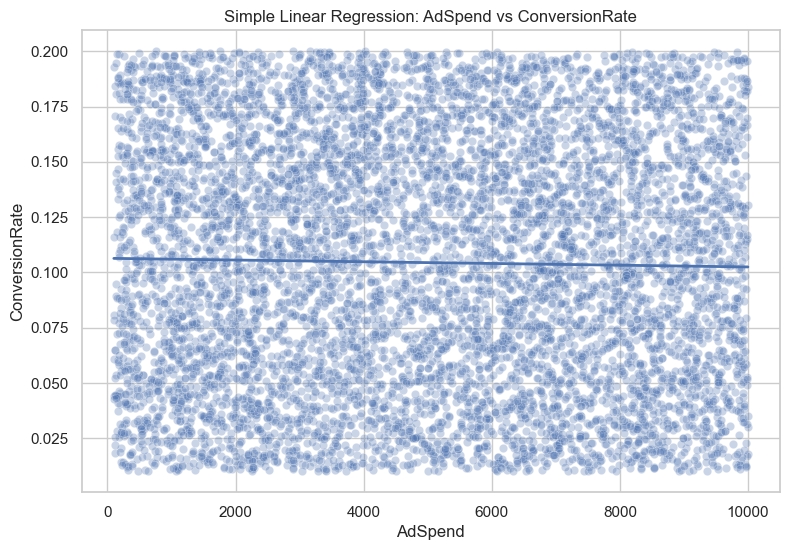

In [17]:
# Create predictions using the simple regression model.

# These predictions are the model's estimated ConversionRate values.

df["ConversionRate_Pred_Simple"] = simple_model.predict(X_simple)


# Create a scatter plot of the real data points.

plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="AdSpend",
    y="ConversionRate",
    alpha=0.3
)


# Add the regression line.
# We sort the values so the line is drawn smoothly from left to right.

df_sorted = df.sort_values("AdSpend")

plt.plot(
    df_sorted["AdSpend"],
    df_sorted["ConversionRate_Pred_Simple"],
    linewidth=2
)


# Add labels and title.

plt.title("Simple Linear Regression: AdSpend vs ConversionRate")
plt.xlabel("AdSpend")
plt.ylabel("ConversionRate")

plt.show()

## Interpretation of the Simple Regression Plot

The scatter plot shows the relationship between `AdSpend` and `ConversionRate`.

The dots are widely spread across the chart.

The regression line is almost flat.

This means there is no clear strong linear relationship between `AdSpend` and `ConversionRate`.

This matches what I saw earlier:

- Correlation was close to 0.
- The regression slope was almost 0.

### Business interpretation

Higher advertising spend alone does not clearly lead to higher conversion rate in this dataset.

This is realistic in digital marketing because conversion rate depends on many factors, not only spend.

Other important factors may include:

- campaign channel
- campaign type
- click-through rate
- website visits
- time on site
- email clicks
- previous purchases
- loyalty points

### Learning point

This is still useful because it teaches me an important modeling lesson:

A simple model with only one feature may be too weak.

Next, I need to understand residuals and least squares, and later build a multiple regression model using more features.

# 9. Residuals and Least Squares

A residual is the difference between the actual value and the predicted value.

Formula:

`Residual = Actual ConversionRate - Predicted ConversionRate`

In this model:

- actual value = `ConversionRate`
- predicted value = `ConversionRate_Pred_Simple`

The goal of Linear Regression is to find the line that makes the prediction errors as small as possible.

This is called the Least Squares Method.

Least Squares means:

1. calculate each residual
2. square each residual
3. add all squared residuals
4. choose the line where this total is as small as possible

In [18]:
# Calculate residuals.
# Residual = actual value - predicted value.

df["Residual_Simple"] = df["ConversionRate"] - df["ConversionRate_Pred_Simple"]


# Calculate squared residuals.
# Squaring makes all errors positive and gives bigger penalty to larger errors.

df["Squared_Residual_Simple"] = df["Residual_Simple"] ** 2


# Display a few rows to understand the calculation.

display(
    df[
        [
            "AdSpend",
            "ConversionRate",
            "ConversionRate_Pred_Simple",
            "Residual_Simple",
            "Squared_Residual_Simple"
        ]
    ].head()
)


# Calculate the sum of squared errors.
# This is the value Linear Regression tries to minimize.

sum_squared_errors = df["Squared_Residual_Simple"].sum()

print("Sum of Squared Errors:")
print(sum_squared_errors)

,AdSpend,ConversionRate,ConversionRate_Pred_Simple,Residual_Simple,Squared_Residual_Simple
0,"6,497.8701",0.0880,0.1038,-0.0158,0.0002
1,"3,898.6686",0.1827,0.1048,0.0779,0.0061
2,"1,546.4296",0.0764,0.1057,-0.0293,0.0009
3,539.5259,0.0880,0.1061,-0.0181,0.0003
4,"1,678.0436",0.1099,0.1057,0.0043,0.0000


Sum of Squared Errors:
24.080198192094088


## Interpretation of Residuals and Least Squares

The table shows the prediction error for each row.

For example, in the first row:

- actual `ConversionRate` = 0.0880
- predicted `ConversionRate` = 0.1038
- residual = -0.0158

This means the model predicted slightly higher than the actual value.

The `Squared_Residual_Simple` column squares each residual.

Squaring is useful because:

- negative errors become positive
- larger errors get a bigger penalty
- errors do not cancel each other out

The Sum of Squared Errors is:

`24.0802`

This is the total squared error for the simple model using only `AdSpend`.

### Learning point

Linear Regression chooses the line that minimizes this total squared error.

Because the model only uses `AdSpend`, the prediction errors are still quite spread out.

This supports the earlier conclusion:

`AdSpend` alone is not enough to strongly predict `ConversionRate`.

# Evaluate the simple model

## Model Evaluation Metrics Explained

To evaluate the regression model, I use four metrics.

### MAE — Mean Absolute Error

MAE tells the average size of the prediction error.

It answers:

“How wrong is the model on average?”

Lower MAE means a better model.

### MSE — Mean Squared Error

MSE squares the errors before averaging them.

This means large errors are punished more strongly.

Lower MSE means a better model.

### RMSE — Root Mean Squared Error

RMSE is the square root of MSE.

It is easier to understand than MSE because it is in the same unit as the target variable.

For `ConversionRate`, RMSE tells the typical prediction error in conversion-rate points.

### R² — Explained Variation

R² tells how much of the variation in `ConversionRate` is explained by the model.

An R² close to 0 means the model explains very little.

An R² close to 1 means the model explains a lot.

For this simple model using only `AdSpend`, I expect R² to be low because the regression line is almost flat.

In [19]:
# Import regression evaluation metrics.

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


# Actual values

y_actual = df["ConversionRate"]


# Predicted values from the simple model

y_pred_simple = df["ConversionRate_Pred_Simple"]


# MAE: average absolute prediction error

mae_simple = mean_absolute_error(y_actual, y_pred_simple)


# MSE: average squared prediction error

mse_simple = mean_squared_error(y_actual, y_pred_simple)


# RMSE: square root of MSE
# This gives error in the same unit as ConversionRate.

rmse_simple = np.sqrt(mse_simple)


# R²: how much variation is explained by the model

r2_simple = r2_score(y_actual, y_pred_simple)


print("Simple Linear Regression Evaluation")
print("-----------------------------------")
print("MAE:", mae_simple)
print("MSE:", mse_simple)
print("RMSE:", rmse_simple)
print("R²:", r2_simple)

Simple Linear Regression Evaluation
-----------------------------------
MAE: 0.047635739738709534
MSE: 0.003010024774011761
RMSE: 0.05486369267568271
R²: 0.0004074280537947894


# 11. Multiple Linear Regression

The Simple Linear Regression model used only one feature:

`AdSpend`

The result was weak because `AdSpend` alone does not explain `ConversionRate`.

Now I will build a Multiple Linear Regression model.

Multiple Linear Regression uses more than one input feature.

The model idea is:

`ŷ = b₀ + b₁x₁ + b₂x₂ + b₃x₃ + ...`

In this project:

- `ŷ` = predicted `ConversionRate`
- `x₁, x₂, x₃...` = different customer, campaign, and engagement features

This should give the model more information and may improve prediction.

In [20]:
# Select useful numeric features for the first multiple regression model.
# We start with numeric columns only to keep things simple.
# Categorical columns like Gender and CampaignChannel will be handled later.

numeric_features = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]

# Create the input table X using the selected features.
X_multi = df[numeric_features]

# Create the target variable y.
y_multi = df["ConversionRate"]

# Check the shape of X and y.
print("X_multi shape:", X_multi.shape)
print("y_multi shape:", y_multi.shape)

# Display the first few rows of X.
display(X_multi.head())

X_multi shape: (8000, 12)
y_multi shape: (8000,)


,Age,Income,AdSpend,ClickThroughRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints
0,56,136912,"6,497.8701",0.0439,0,2.3990,7.3968,19,6,9,4,688
1,69,41760,"3,898.6686",0.1557,42,2.9171,5.3525,5,2,7,2,3459
2,46,88456,"1,546.4296",0.2775,2,8.2236,13.7949,0,11,2,8,2337
3,32,44085,539.5259,0.1376,47,4.5409,14.6884,89,2,2,0,2463
4,60,83964,"1,678.0436",0.2529,0,2.0468,13.9934,6,6,6,8,4345


## Multiple Regression Input Features

For the first Multiple Linear Regression model, I am using only numeric features.

This keeps the model simple and avoids categorical encoding for now.

The input table `X_multi` contains 12 numeric columns.

The target variable `y_multi` is:

`ConversionRate`

So the model will try to learn:

`ConversionRate = relationship between many numeric marketing/customer features`

# Train the Multiple Linear Regression model

In [21]:
# Create a Multiple Linear Regression model.
# This model will use many numeric features to predict ConversionRate.

multi_model = LinearRegression()


# Train the model using all selected numeric features.
# The model learns one intercept and one coefficient for each feature.

multi_model.fit(X_multi, y_multi)


# Extract the intercept.
# Intercept is the starting value of the model.

multi_intercept = multi_model.intercept_


# Extract coefficients.
# Each feature gets one coefficient.

multi_coefficients = multi_model.coef_


print("Multiple Linear Regression model trained successfully.")
print("Intercept:", multi_intercept)
print("Number of coefficients:", len(multi_coefficients))

Multiple Linear Regression model trained successfully.
Intercept: 0.10007114691537627
Number of coefficients: 12


## Multiple Regression Coefficients

Coefficients tells: When this feature increases by 1, how does predicted ConversionRate change,
assuming other features stay the same?

Now I will inspect the coefficients of the Multiple Linear Regression model.

Each feature gets one coefficient.

A coefficient tells the direction of the relationship:

- positive coefficient: feature is associated with higher predicted `ConversionRate`
- negative coefficient: feature is associated with lower predicted `ConversionRate`

Important: coefficient does not automatically prove causation.

In [22]:
# Create a dataframe to show each feature and its coefficient.
# This makes the model easier to interpret.

coefficients_df = pd.DataFrame({
    "Feature": numeric_features,
    "Coefficient": multi_coefficients
})


# Add absolute coefficient value.
# This helps us sort by size, regardless of positive or negative direction.

coefficients_df["Absolute_Coefficient"] = coefficients_df["Coefficient"].abs()


# Sort features by absolute coefficient size.

coefficients_df = coefficients_df.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)


# Display the coefficients table.

display(coefficients_df)

,Feature,Coefficient,Absolute_Coefficient
3,ClickThroughRate,-0.0057,0.0057
10,PreviousPurchases,-0.0004,0.0004
5,PagesPerVisit,0.0004,0.0004
9,EmailClicks,0.0001,0.0001
6,TimeOnSite,0.0001,0.0001
0,Age,0.0001,0.0001
8,EmailOpens,0.0001,0.0001
4,WebsiteVisits,-0.0000,0.0000
7,SocialShares,0.0000,0.0000
2,AdSpend,-0.0000,0.0000


## Interpretation of Multiple Regression Coefficients

The coefficient table shows how each numeric feature is associated with predicted `ConversionRate`.

A positive coefficient means the feature is associated with a higher predicted `ConversionRate`.

A negative coefficient means the feature is associated with a lower predicted `ConversionRate`.

In this model, most coefficients are very close to zero.

This suggests that the numeric features alone do not strongly explain `ConversionRate`.

The largest coefficient by absolute value is for `ClickThroughRate`, but even this value is quite small.

Important:

These coefficients show association, not causation.

So I should not say that a feature causes conversion rate to increase or decrease. I should say that the feature is associated with predicted conversion rate in this model.

# 12. Evaluate the Multiple Linear Regression Model

Now I will evaluate the Multiple Linear Regression model.

This model uses 12 numeric input features instead of only `AdSpend`.

I will use the same metrics as before:

- MAE
- MSE
- RMSE
- R²

Then I will compare this model with the Simple Linear Regression model.

In [23]:
# Create predictions using the multiple regression model.
# These are the model's predicted ConversionRate values.

y_pred_multi = multi_model.predict(X_multi)


# Calculate model evaluation metrics.

mae_multi = mean_absolute_error(y_multi, y_pred_multi)

mse_multi = mean_squared_error(y_multi, y_pred_multi)

rmse_multi = np.sqrt(mse_multi)

r2_multi = r2_score(y_multi, y_pred_multi)


print("Multiple Linear Regression Evaluation")
print("-------------------------------------")
print("MAE:", mae_multi)
print("MSE:", mse_multi)
print("RMSE:", rmse_multi)
print("R²:", r2_multi)

Multiple Linear Regression Evaluation
-------------------------------------
MAE: 0.047575421533762166
MSE: 0.0030040713206059503
RMSE: 0.05480940905178554
R²: 0.0023844974298533606


## Interpretation of Multiple Linear Regression Evaluation

he multiple regression model improved only very slightly.

Simple model R²:   0.0004
Multiple model R²: 0.0024

The Multiple Linear Regression model used 12 numeric input features.

The results were:

- MAE: 0.0476
- MSE: 0.0030
- RMSE: 0.0548
- R²: 0.0024

Compared with the Simple Linear Regression model, the result improved only very slightly.

The R² value is still very close to 0.

This means the model explains only a very small part of the variation in `ConversionRate`.

### Business interpretation

The numeric features alone are not enough to strongly predict `ConversionRate` using a linear regression model.

Possible reasons:

- The relationship may not be linear.
- Important categorical variables are not included yet.
- `ConversionRate` may be generated with randomness.
- A more advanced model may be needed.
- The dataset may be synthetic.

### Learning point

Adding more features does not automatically create a good model.

A professional analyst must always check model performance instead of assuming the model is useful.

# Simple Model Vs Multiple Model

In [24]:
# Compare the simple model and multiple model side by side.
# This helps us see whether the multiple model improved performance.

model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression: AdSpend only",
        "Multiple Linear Regression: numeric features"
    ],
    "MAE": [
        mae_simple,
        mae_multi
    ],
    "MSE": [
        mse_simple,
        mse_multi
    ],
    "RMSE": [
        rmse_simple,
        rmse_multi
    ],
    "R2": [
        r2_simple,
        r2_multi
    ]
})

display(model_comparison)

,Model,MAE,MSE,RMSE,R2
0,Simple Linear Regression: AdSpend only,0.0476,0.0030,0.0549,0.0004
1,Multiple Linear Regression: numeric features,0.0476,0.0030,0.0548,0.0024


## Model Comparison Interpretation

The comparison table shows that the Multiple Linear Regression model performs only slightly better than the Simple Linear Regression model.

The Simple Linear Regression model has:

- R² = 0.0004

The Multiple Linear Regression model has:

- R² = 0.0024

Both R² values are very close to 0.

This means both models explain very little of the variation in `ConversionRate`.

The Multiple Linear Regression model is slightly better, but the improvement is very small.

### Key learning

Adding more features does not automatically make a model useful.

A professional analyst must compare model performance and check whether the improvement is meaningful.

# 13. Train/Test Split

So far, I trained and evaluated the model on the same dataset.

This is not the best professional approach.

A model should be tested on data it has not seen before.

So I will split the data into:

- training data: used to train the model
- test data: used to evaluate the model

This helps me understand how the model may perform on new unseen data.

In [25]:
# Import train_test_split.
# This function splits the dataset into training and testing parts.

from sklearn.model_selection import train_test_split


# Split the data.
# test_size=0.2 means 20% of the data will be used for testing.
# random_state=42 makes the split reproducible.

X_train, X_test, y_train, y_test = train_test_split(
    X_multi,
    y_multi,
    test_size=0.2,
    random_state=42
)


# Print the shapes to confirm the split.

print("Training feature data shape:", X_train.shape)
print("Testing feature data shape:", X_test.shape)

print("Training target data shape:", y_train.shape)
print("Testing target data shape:", y_test.shape)

Training feature data shape: (6400, 12)
Testing feature data shape: (1600, 12)
Training target data shape: (6400,)
Testing target data shape: (1600,)


## Train/Test Split Summary

The dataset was split into:

- 6,400 rows for training
- 1,600 rows for testing

The training data is used to teach the model.

The test data is used to check how the model performs on unseen data.

This is more professional than evaluating the model on the same data it was trained on.

# 14. Train and Evaluate Model on Test Data

Now I will train the Multiple Linear Regression model using only the training data.

Then I will use the trained model to predict `ConversionRate` for the test data.

This gives a more realistic evaluation because the test data was not used during training.

In [26]:
# Create a new Multiple Linear Regression model.
# I create a new model so this train/test version is separate from the earlier full-data model.

train_test_model = LinearRegression()


# Train the model only on the training data.

train_test_model.fit(X_train, y_train)


# Predict ConversionRate for the training data.

y_train_pred = train_test_model.predict(X_train)


# Predict ConversionRate for the test data.

y_test_pred = train_test_model.predict(X_test)


print("Model trained on training data and predictions created.")

Model trained on training data and predictions created.


## Train vs Test Evaluation

Now I will calculate model performance on both training and test data.

This helps answer:

- How well did the model perform on data it learned from?
- How well did the model perform on new unseen data?

If training performance is much better than test performance, the model may be overfitting.

If both are weak, the model itself may not be useful for this target.

In [27]:
# Create a helper function to calculate regression metrics.
# This avoids repeating the same code multiple times.

def regression_metrics(y_true, y_pred):
    """
    Calculates common regression evaluation metrics.
    
    y_true = actual values
    y_pred = predicted values
    """
    
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    return mae, mse, rmse, r2


# Calculate metrics for training data.

train_mae, train_mse, train_rmse, train_r2 = regression_metrics(
    y_train,
    y_train_pred
)


# Calculate metrics for test data.

test_mae, test_mse, test_rmse, test_r2 = regression_metrics(
    y_test,
    y_test_pred
)


# Create a comparison table.

train_test_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [train_mae, test_mae],
    "MSE": [train_mse, test_mse],
    "RMSE": [train_rmse, test_rmse],
    "R2": [train_r2, test_r2]
})


# Display the result table.

display(train_test_results)

,Dataset,MAE,MSE,RMSE,R2
0,Train,0.0478,0.0030,0.0550,0.0019
1,Test,0.0468,0.0029,0.0540,0.0015


## Train/Test Evaluation Interpretation

The train and test results are very similar.

Training performance:

- MAE: 0.0478
- RMSE: 0.0550
- R²: 0.0019

Test performance:

- MAE: 0.0468
- RMSE: 0.0540
- R²: 0.0015

### What this means

The model performs almost the same on training data and test data.

This means the model is not overfitting.

However, the R² values are very close to 0.

This means the model explains almost none of the variation in `ConversionRate`.

### Business interpretation

The numeric features used in this model do not strongly predict `ConversionRate` using a linear regression approach.

The model is stable, but weak.

This suggests that:

- the relationship may not be linear
- important categorical features may be missing
- conversion rate may depend on more complex interactions
- another model type may be needed later

### Professional conclusion

This model is useful for learning Linear Regression, but it is not a strong business prediction model yet.

# 15. Actual vs Predicted Values

Now I will compare the actual `ConversionRate` values with the model's predicted values.

If the model is good, the points should be close to a diagonal line.

If the points are scattered, the model is not predicting well.

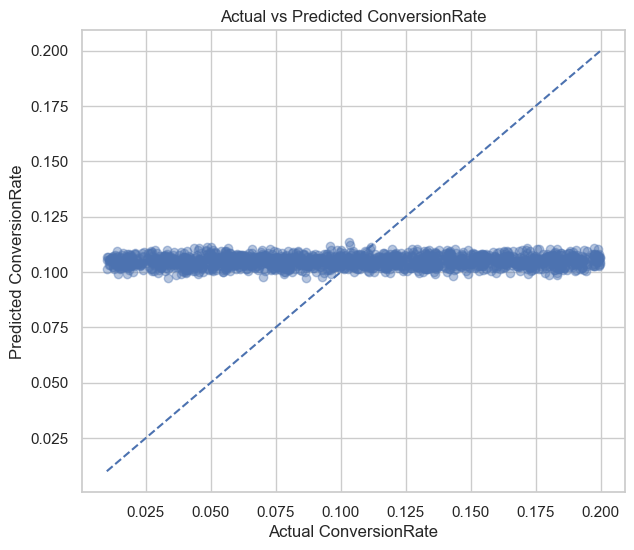

In [28]:
# Create a scatter plot of actual vs predicted ConversionRate.
# x-axis = actual values
# y-axis = predicted values

plt.figure(figsize=(7, 6))

plt.scatter(
    y_test,
    y_test_pred,
    alpha=0.4
)

# Add a reference diagonal line.
# A perfect model would place points close to this line.

min_value = min(y_test.min(), y_test_pred.min())
max_value = max(y_test.max(), y_test_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs Predicted ConversionRate")
plt.xlabel("Actual ConversionRate")
plt.ylabel("Predicted ConversionRate")

plt.show()

## Interpretation of Actual vs Predicted Plot

The dashed diagonal line represents perfect predictions.

If the model were strong, the points would be close to this diagonal line.

However, the points are mostly clustered in a horizontal band around 0.10 to 0.11.

This means the model is predicting values close to the average `ConversionRate` for most records.

The model is not adjusting predictions strongly based on the input features.

This matches the low R² value.

### Business interpretation

The numeric features used in this model do not provide enough linear signal to predict `ConversionRate` well.

The model is stable, but it is too weak for strong business prediction.

### Learning point

When predictions are almost flat, it usually means the model is behaving like:

"Predict the average for everyone."

This is not useful for strong prediction, but it is very useful for learning how to diagnose a weak regression model.

# 16. Residual Plot

A residual is the difference between the actual value and the predicted value.

Formula:

`Residual = Actual ConversionRate - Predicted ConversionRate`

A residual plot helps me check whether the model errors have a pattern.

If the model is good, residuals should be randomly scattered around 0.

If there is a clear pattern, the model may be missing something.

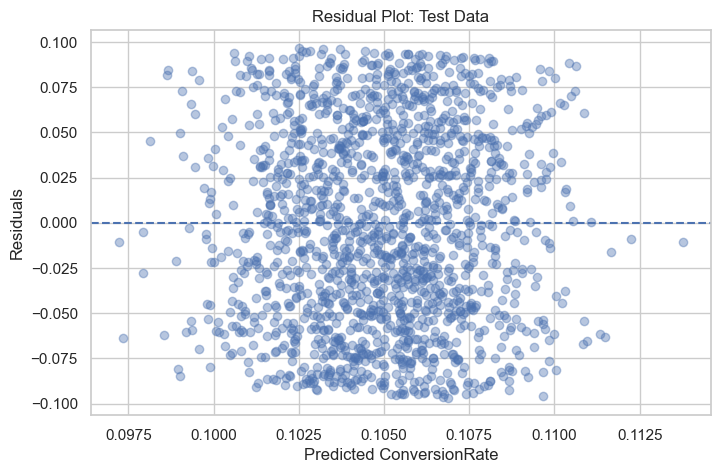

In [29]:
# Calculate residuals for the test data.
# Residual = actual value - predicted value

test_residuals = y_test - y_test_pred


# Create residual plot.
# x-axis = predicted values
# y-axis = residuals

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test_pred,
    test_residuals,
    alpha=0.4
)


# Add a horizontal line at 0.
# This helps us see whether errors are centered around zero.

plt.axhline(
    y=0,
    linestyle="--"
)


plt.title("Residual Plot: Test Data")
plt.xlabel("Predicted ConversionRate")
plt.ylabel("Residuals")

plt.show()

## Interpretation of Residual Plot

The residual plot shows the model errors on the test data.

The residuals are spread above and below the zero line.

However, the predicted values are concentrated in a very narrow range around 0.10 to 0.11.

This means the model is mostly predicting values close to the average `ConversionRate`.

The actual errors are still quite large, ranging roughly from -0.10 to +0.10.

### What this tells me

The model is not learning strong patterns from the numeric features.

It is behaving almost like an average-prediction model.

This matches the low R² value.

### Business interpretation

The numeric features alone are not enough to build a strong linear regression model for `ConversionRate`.

To improve the model, I may need to:

- include categorical variables such as `CampaignChannel` and `CampaignType`
- try non-linear models later
- investigate whether the dataset is synthetic
- use classification for the binary `Conversion` column

# 17. Business Interpretation and Conclusion

The goal of this notebook was to apply Day 1 Linear Regression concepts to a digital marketing dataset.

The main target variable was:

`ConversionRate`

I started with a Simple Linear Regression model using only:

`AdSpend`

Then I built a Multiple Linear Regression model using 12 numeric features.

## Main Findings

### 1. AdSpend alone is not a strong predictor

The Simple Linear Regression model using only `AdSpend` had a very low R² value.

This means that advertising spend alone does not explain much of the variation in `ConversionRate`.

This is realistic because conversion rate depends on more than just spend.

### 2. Numeric features improved the model only slightly

The Multiple Linear Regression model used numeric features such as:

- Age
- Income
- AdSpend
- ClickThroughRate
- WebsiteVisits
- PagesPerVisit
- TimeOnSite
- SocialShares
- EmailOpens
- EmailClicks
- PreviousPurchases
- LoyaltyPoints

However, the model still had a very low R² value.

This means these numeric features do not strongly explain `ConversionRate` using a linear model.

### 3. The model mostly predicts close to the average

The actual vs predicted plot showed that predictions were concentrated around 0.10 to 0.11.

This means the model is mostly predicting close to the average `ConversionRate`.

It is not strongly adjusting predictions based on the input features.

### 4. The model is stable but weak

The train and test performance were similar.

This means the model is not overfitting.

However, both train and test R² values were very low.

So the model is stable, but not very useful for strong prediction.

## Professional Conclusion

This analysis shows that Linear Regression is useful for learning the modeling process, but it is not strong enough for this dataset when using only numeric features.

The current model should not be used as a final business prediction model.

It is useful as a baseline model.

## Recommended Next Steps

To improve the analysis, I would next:

1. Include categorical features such as `CampaignChannel`, `CampaignType`, and `Gender`.
2. Encode categorical variables using one-hot encoding.
3. Try classification using the `Conversion` column.
4. Test non-linear models such as Decision Tree or Random Forest.
5. Compare model performance across different approaches.

## Final Learning

The most important learning from this notebook is:

Adding more features does not automatically create a better model.

A professional analyst must always:

- inspect the data
- visualize relationships
- check residuals
- evaluate train and test performance
- interpret results carefully
- avoid claiming causation from correlation

# Step 18 — Include Categorical Variables
We already used numeric columns. Now we will include useful text/category columns:

So far, the Multiple Linear Regression model used only numeric features.

However, some important marketing information is categorical.

Examples:

- `Gender`
- `CampaignChannel`
- `CampaignType`

Machine learning models cannot directly understand text values like:

`Email`, `PPC`, `Social Media`, `Awareness`, `Conversion`

So I need to convert these categories into numeric columns.

This process is called:

`One-Hot Encoding`

One-hot encoding creates separate 0/1 columns for each category.

In [30]:
# Check the useful categorical columns.
# These are text columns that may contain useful marketing information.

categorical_features = [
    "Gender",
    "CampaignChannel",
    "CampaignType"
]


# Print unique values for each categorical column.
# This helps us understand what categories exist before encoding.

for col in categorical_features:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())


Column: Gender
Gender
Female    4839
Male      3161
Name: count, dtype: int64

Column: CampaignChannel
CampaignChannel
Referral        1719
PPC             1655
Email           1557
SEO             1550
Social Media    1519
Name: count, dtype: int64

Column: CampaignType
CampaignType
Conversion       2077
Awareness        1988
Consideration    1988
Retention        1947
Name: count, dtype: int64


## Interpretation of Categorical Columns

The dataset has three useful categorical columns:

### Gender

There are two categories:

- Female: 4839 records
- Male: 3161 records

### CampaignChannel

There are five campaign channels:

- Referral
- PPC
- Email
- SEO
- Social Media

The counts are fairly balanced across channels.

### CampaignType

There are four campaign types:

- Conversion
- Awareness
- Consideration
- Retention

These counts are also fairly balanced.

These categorical variables may contain useful marketing information, so I will include them in the next regression model using one-hot encoding.

# 19. One-Hot Encoding

Linear Regression can only work with numbers.

Categorical values like `Email`, `PPC`, or `Social Media` are text, so the model cannot use them directly.

One-hot encoding converts categories into numeric 0/1 columns.

Example:

If `CampaignChannel` has values:

- Email
- PPC
- SEO

One-hot encoding creates columns like:

- CampaignChannel_Email
- CampaignChannel_PPC
- CampaignChannel_SEO

Each row gets 1 if the category is present, otherwise 0.

In [31]:
# Create a new dataframe for the encoded model.
# I start from the original dataset.

df_encoded = df.copy()


# Select columns that should NOT be used as input features.

columns_to_drop = [
    "CustomerID",             # ID column, not useful for prediction
    "AdvertisingPlatform",    # technical/confidential column
    "AdvertisingTool",        # technical/confidential column
    "Conversion",             # classification target, not used in this regression model
    "ConversionRate"          # regression target, must not be inside input features
]


# Create X by dropping columns that should not be input features.

X_with_categories = df_encoded.drop(columns=columns_to_drop)


# Create y as the regression target.

y_with_categories = df_encoded["ConversionRate"]


# Convert categorical columns into dummy/one-hot encoded columns.
# drop_first=True avoids duplicate information between categories.

X_with_categories_encoded = pd.get_dummies(
    X_with_categories,
    drop_first=True
)


# Convert any True/False dummy columns into 1/0 integers.

X_with_categories_encoded = X_with_categories_encoded.astype(float)


print("Shape before encoding:", X_with_categories.shape)
print("Shape after encoding:", X_with_categories_encoded.shape)

display(X_with_categories_encoded.head())

Shape before encoding: (8000, 19)
Shape after encoding: (8000, 24)


,Age,Income,AdSpend,ClickThroughRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,AdSpend_Deviation,ConversionRate_Pred_Simple,Residual_Simple,Squared_Residual_Simple,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56.0000,"136,912.0000","6,497.8701",0.0439,0.0000,2.3990,7.3968,19.0000,6.0000,9.0000,4.0000,688.0000,"1,496.9252",0.1038,-0.0158,0.0002,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,69.0000,"41,760.0000","3,898.6686",0.1557,42.0000,2.9171,5.3525,5.0000,2.0000,7.0000,2.0000,"3,459.0000","-1,102.2762",0.1048,0.0779,0.0061,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,46.0000,"88,456.0000","1,546.4296",0.2775,2.0000,8.2236,13.7949,0.0000,11.0000,2.0000,8.0000,"2,337.0000","-3,454.5152",0.1057,-0.0293,0.0009,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,32.0000,"44,085.0000",539.5259,0.1376,47.0000,4.5409,14.6884,89.0000,2.0000,2.0000,0.0000,"2,463.0000","-4,461.4189",0.1061,-0.0181,0.0003,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
4,60.0000,"83,964.0000","1,678.0436",0.2529,0.0000,2.0468,13.9934,6.0000,6.0000,6.0000,8.0000,"4,345.0000","-3,322.9013",0.1057,0.0043,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


## Fixing the Encoded Feature Table

The previous encoded table accidentally included columns created during earlier modeling, such as residuals and predictions.

These columns should not be used as input features.

For a clean model, I will manually select only the original useful columns:

- numeric customer/campaign/engagement features
- categorical features after one-hot encoding

I will exclude:

- target columns
- ID columns
- technical columns
- columns created during earlier analysis

In [32]:
# Define clean numeric features.
# These are original numeric columns from the dataset.

numeric_features_clean = [
    "Age",
    "Income",
    "AdSpend",
    "ClickThroughRate",
    "WebsiteVisits",
    "PagesPerVisit",
    "TimeOnSite",
    "SocialShares",
    "EmailOpens",
    "EmailClicks",
    "PreviousPurchases",
    "LoyaltyPoints"
]


# Define useful categorical features.
# These are original text columns that may contain useful business information.

categorical_features_clean = [
    "Gender",
    "CampaignChannel",
    "CampaignType"
]


# Combine numeric and categorical features into one feature list.

features_clean = numeric_features_clean + categorical_features_clean


# Create a clean input table using only selected original features.

X_clean = df[features_clean]


# Create the target variable.

y_clean = df["ConversionRate"]


# Apply one-hot encoding to categorical columns.
# drop_first=True removes one category from each categorical feature to avoid duplicate information.

X_clean_encoded = pd.get_dummies(
    X_clean,
    drop_first=True
)


# Convert dummy columns from True/False to 1/0 style numbers.

X_clean_encoded = X_clean_encoded.astype(float)


print("Clean feature table before encoding:", X_clean.shape)
print("Clean feature table after encoding:", X_clean_encoded.shape)

display(X_clean_encoded.head())

Clean feature table before encoding: (8000, 15)
Clean feature table after encoding: (8000, 20)


,Age,Income,AdSpend,ClickThroughRate,WebsiteVisits,PagesPerVisit,TimeOnSite,SocialShares,EmailOpens,EmailClicks,PreviousPurchases,LoyaltyPoints,Gender_Male,CampaignChannel_PPC,CampaignChannel_Referral,CampaignChannel_SEO,CampaignChannel_Social Media,CampaignType_Consideration,CampaignType_Conversion,CampaignType_Retention
0,56.0000,"136,912.0000","6,497.8701",0.0439,0.0000,2.3990,7.3968,19.0000,6.0000,9.0000,4.0000,688.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000
1,69.0000,"41,760.0000","3,898.6686",0.1557,42.0000,2.9171,5.3525,5.0000,2.0000,7.0000,2.0000,"3,459.0000",1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000
2,46.0000,"88,456.0000","1,546.4296",0.2775,2.0000,8.2236,13.7949,0.0000,11.0000,2.0000,8.0000,"2,337.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,32.0000,"44,085.0000",539.5259,0.1376,47.0000,4.5409,14.6884,89.0000,2.0000,2.0000,0.0000,"2,463.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000
4,60.0000,"83,964.0000","1,678.0436",0.2529,0.0000,2.0468,13.9934,6.0000,6.0000,6.0000,8.0000,"4,345.0000",0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000


## Interpretation of Clean Encoded Feature Table

The clean encoded feature table now contains only useful input features.

It includes:

- original numeric features such as `Age`, `Income`, `AdSpend`, `ClickThroughRate`, and engagement metrics
- encoded categorical features such as `Gender_Male`, `CampaignChannel_PPC`, and `CampaignType_Conversion`

The categorical columns have been converted into 0/1 numeric columns.

For example:

`Gender_Male = 1` means the customer is male.

`Gender_Male = 0` means the customer belongs to the dropped reference category, which is female.

This clean encoded table is now ready for a new Multiple Linear Regression model.

# 20. Multiple Linear Regression with Numeric and Categorical Features

Now I will build a new Multiple Linear Regression model using:

- numeric features
- one-hot encoded categorical features

This model has more information than the previous numeric-only model.

The goal is to check whether adding categorical marketing information improves prediction performance.

In [33]:
# Split the clean encoded data into training and test sets.
# 80% will be used for training and 20% for testing.

X_train_cat, X_test_cat, y_train_cat, y_test_cat = train_test_split(
    X_clean_encoded,
    y_clean,
    test_size=0.2,
    random_state=42
)


# Create a new Linear Regression model.

cat_model = LinearRegression()


# Train the model on the training data.

cat_model.fit(X_train_cat, y_train_cat)


# Create predictions for training and test data.

y_train_cat_pred = cat_model.predict(X_train_cat)
y_test_cat_pred = cat_model.predict(X_test_cat)


print("Model with numeric and categorical features trained successfully.")
print("Training shape:", X_train_cat.shape)
print("Testing shape:", X_test_cat.shape)

Model with numeric and categorical features trained successfully.
Training shape: (6400, 20)
Testing shape: (1600, 20)


## Evaluation of Model with Categorical Features

Now I will evaluate the model that includes both:

- numeric features
- one-hot encoded categorical features

I will compare train and test performance using:

- MAE
- MSE
- RMSE
- R²

This will show whether categorical features improved the model.

In [36]:
# Calculate regression metrics for the model with categorical features.
# We use the same helper function created earlier: regression_metrics()

cat_train_mae, cat_train_mse, cat_train_rmse, cat_train_r2 = regression_metrics(
    y_train_cat,
    y_train_cat_pred
)

cat_test_mae, cat_test_mse, cat_test_rmse, cat_test_r2 = regression_metrics(
    y_test_cat,
    y_test_cat_pred
)


# Create evaluation table for train and test performance.

cat_model_results = pd.DataFrame({
    "Dataset": ["Train", "Test"],
    "MAE": [cat_train_mae, cat_test_mae],
    "MSE": [cat_train_mse, cat_test_mse],
    "RMSE": [cat_train_rmse, cat_test_rmse],
    "R2": [cat_train_r2, cat_test_r2]
})


# Display the result table.

display(cat_model_results)

,Dataset,MAE,MSE,RMSE,R2
0,Train,0.0477,0.0030,0.0550,0.0032
1,Test,0.0469,0.0029,0.0541,-0.0023


## Interpretation of Model with Categorical Features

After adding categorical variables, the model results were:

Training performance:

- MAE: 0.0477
- RMSE: 0.0550
- R²: 0.0032

Test performance:

- MAE: 0.0469
- RMSE: 0.0541
- R²: -0.0023

The training R² is still very close to 0.

The test R² is negative.

A negative test R² means the model performs worse than a simple baseline model that predicts the average `ConversionRate`.

### Business interpretation

Adding categorical features such as `Gender`, `CampaignChannel`, and `CampaignType` did not improve the Linear Regression model.

This suggests that `ConversionRate` is not well explained by these features using a linear regression approach.

### Professional conclusion

The model is stable, but weak.

For this dataset, Linear Regression is useful for learning the workflow, but it is not strong enough as a prediction model for `ConversionRate`.

A better next step would be to treat `Conversion` as a classification problem.

In [37]:
# Compare all regression models created so far.

all_model_comparison = pd.DataFrame({
    "Model": [
        "Simple Linear Regression: AdSpend only",
        "Multiple Regression: numeric features",
        "Multiple Regression: numeric + categorical features"
    ],
    "Test MAE": [
        mae_simple,
        test_mae,
        cat_test_mae
    ],
    "Test RMSE": [
        rmse_simple,
        test_rmse,
        cat_test_rmse
    ],
    "Test R2": [
        r2_simple,
        test_r2,
        cat_test_r2
    ]
})

display(all_model_comparison)

,Model,Test MAE,Test RMSE,Test R2
0,Simple Linear Regression: AdSpend only,0.0476,0.0549,0.0004
1,Multiple Regression: numeric features,0.0468,0.0540,0.0015
2,Multiple Regression: numeric + categorical fea...,0.0469,0.0541,-0.0023


## Final Regression Model Comparison

I compared three regression models:

1. Simple Linear Regression using only `AdSpend`
2. Multiple Linear Regression using numeric features
3. Multiple Linear Regression using numeric and categorical features

The results show that all three models have very low R² values.

The best test R² came from the numeric-feature Multiple Regression model:

`R² = 0.0015`

However, this is still extremely close to 0.

This means the model explains almost none of the variation in `ConversionRate`.

The model with categorical features had a negative test R²:

`R² = -0.0023`

This means it performed worse than simply predicting the average `ConversionRate`.

### Main conclusion

Linear Regression is not a strong model for predicting `ConversionRate` in this dataset.

This does not mean the analysis failed.

It means the analysis gave a clear professional finding:

`ConversionRate` is not well explained by these features using a linear regression approach.

### Best next step

Since the dataset also contains a binary `Conversion` column, the next better modeling direction is classification.

Instead of asking:

"Can we predict the exact ConversionRate?"

we can ask:

"Can we predict whether a customer converts or not?"

That is a classification problem, and Logistic Regression is a good next model to try.